In [1]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from chronos import BaseChronosPipeline, Chronos2Pipeline
import datetime

pipeline: Chronos2Pipeline = BaseChronosPipeline.from_pretrained("amazon/chronos-2", device_map="cuda")

# Constants
DATASET_DIR = "../../../../../datasets"

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

# Utilities

In [2]:
# Visualization helper function taken from https://github.com/amazon-science/chronos-forecasting/blob/main/notebooks/chronos-2-quickstart.ipynb
def plot_forecast(
    context_df: pd.DataFrame,
    pred_df: pd.DataFrame,
    test_df: pd.DataFrame,
    target_column: str,
    timeseries_id: str,
    id_column: str = "id",
    timestamp_column: str = "timestamp",
    history_length: int = 256,
    title_suffix: str = "",
    plot_name = ""
):
    ts_context = context_df.query(f"{id_column} == @timeseries_id").set_index(timestamp_column)[target_column]
    ts_pred = pred_df.query(f"{id_column} == @timeseries_id and target_name == @target_column").set_index(
        timestamp_column
    )[["0.1", "predictions", "0.9"]]
    ts_ground_truth = test_df.query(f"{id_column} == @timeseries_id").set_index(timestamp_column)[target_column]

    last_date = ts_context.index.max()
    start_idx = max(0, len(ts_context) - history_length)
    plot_cutoff = ts_context.index[start_idx]
    ts_context = ts_context[ts_context.index >= plot_cutoff]
    ts_pred = ts_pred[ts_pred.index >= plot_cutoff]
    ts_ground_truth = ts_ground_truth[ts_ground_truth.index >= plot_cutoff]

    fig = plt.figure(figsize=(12, 3))
    ax = fig.gca()
    ts_context.plot(ax=ax, label=f"historical {target_column}", color="xkcd:azure")
    ts_ground_truth.plot(ax=ax, label=f"future {target_column} (ground truth)", color="xkcd:grass green")
    ts_pred["predictions"].plot(ax=ax, label="forecast", color="xkcd:violet")
    ax.fill_between(
        ts_pred.index,
        ts_pred["0.1"],
        ts_pred["0.9"],
        alpha=0.7,
        label="prediction interval",
        color="xkcd:light lavender",
    )
    ax.axvline(x=last_date, color="black", linestyle="--", alpha=0.5)
    ax.legend(loc="upper left")
    ax.set_title(f"{target_column} forecast for {timeseries_id} {title_suffix}")
    fig.show()

    plot_timestamp = datetime.datetime.now().strftime('%Y-%m-%d_%H:%M:%S')
    plot_filename = f"{plot_name}-{plot_timestamp}" if plot_name else plot_timestamp 
    
    fig.savefig(f"/home/cloudsherpa-collab/forecast_plots/{plot_filename}.png", dpi=300, bbox_inches='tight')

In [3]:
def sherpa_chronos_preprocess(
    path: str
):
    rename_columns = {
        "resourceId": "item_id",
        "value": "target"
    }

    keep_columns = ["resourceId", "value", "metricName", "timestamp"]

    # Not handling FileNotFoundError, want runtime error to be thrown if that happens
    context_df = pd.read_csv(path)
    
    context_df = context_df[keep_columns].copy()
    context_df = context_df.rename(columns=rename_columns)

    context_df["item_id"] = context_df["item_id"].astype(str)
    context_df["timestamp"] = pd.to_datetime(context_df['timestamp'], format='ISO8601', utc=True).dt.tz_convert("UTC").dt.tz_localize(None)
    context_df = context_df.dropna(subset=["timestamp"]).sort_values(by="timestamp")
    
    return context_df

def sherpa_get_feature(
    context_df: pd.DataFrame,
    resource_id: str,
    metricName: str,
):
    return context_df.loc[(context_df["item_id"] == resource_id) & (context_df["metricName"] == metricName)].copy()

def sherpa_combine_resources(
    context_df: pd.DataFrame,
    resource_id: str,
    target_metric: str
):

    resource_df = context_df.loc[context_df["item_id"] == resource_id]
    
    # Get all metric types for resource
    metric_types = resource_df["metricName"].unique()
    metric_types = np.delete(metric_types, np.where(metric_types == target_metric))
    
    target_df = resource_df.loc[resource_df["metricName"] == target_metric]
    
    for metric in metric_types:
        # construct merge df
        merge_df = resource_df.loc[resource_df["metricName"] == metric].drop(columns="metricName")
        merge_df = merge_df.rename(columns={"target": metric})
        # merge
        target_df = target_df.merge(merge_df, on=["item_id", "timestamp"])

    return target_df
    

In [4]:
def quantify_error_rmse(
    ground_truth_df: pd.DataFrame,
    prediction_df: pd.DataFrame
):
    rmse = np.sqrt(
        np.mean(
            (
                ground_truth_df["target"].to_numpy()
                - prediction_df["predictions"].to_numpy()
            ) ** 2
        )
    )
    print(f"Root Mean Squared Error: {rmse}")
    return rmse

In [5]:
mock_context_df = sherpa_chronos_preprocess(f"{DATASET_DIR}/mockDataset.csv")

print(mock_context_df.shape)
print(mock_context_df.head())

(160722, 4)
                     item_id     target                  metricName  timestamp
0        i-0ec321a1c8ed4915c  44.108112              CPUUtilization 2026-05-01
20162  cloudsherpa-prod-data  10.349822                 AllRequests 2026-05-01
20163  cloudsherpa-prod-data   0.134197            FirstByteLatency 2026-05-01
15842             UsersTable  57.807130          ReadThrottleEvents 2026-05-01
15841             UsersTable  49.488796  ConsumedWriteCapacityUnits 2026-05-01


# Test Univariate with Mock Data

In [6]:
mock_cpu_df = sherpa_get_feature(mock_context_df, "i-0ec321a1c8ed4915c", "CPUUtilization")
display(mock_cpu_df.shape)
test_size=612
mock_cpu_train = mock_cpu_df.iloc[:-test_size].copy()
mock_cpu_test = mock_cpu_df.iloc[-test_size:].copy()
display(mock_cpu_train.shape)
display(mock_cpu_test.shape)
display(mock_cpu_test.tail())

(8929, 4)

(8317, 4)

(612, 4)

,item_id,target,metricName,timestamp
156372,i-0ec321a1c8ed4915c,45.445015,CPUUtilization,2026-05-31 23:40:00
156375,i-0ec321a1c8ed4915c,39.570892,CPUUtilization,2026-05-31 23:45:00
156378,i-0ec321a1c8ed4915c,33.288518,CPUUtilization,2026-05-31 23:50:00
156381,i-0ec321a1c8ed4915c,35.113337,CPUUtilization,2026-05-31 23:55:00
156384,i-0ec321a1c8ed4915c,20.049814,CPUUtilization,2026-06-01 00:00:00


In [7]:
# Make prediction
pred_df = pipeline.predict_df(mock_cpu_train, prediction_length=test_size, quantile_levels=[0.1, 0.5, 0.9], freq="5min")
print(pred_df.iloc[0])

item_id        i-0ec321a1c8ed4915c
timestamp      2026-05-29 21:05:00
target_name                 target
predictions              23.475277
0.1                       19.42123
0.5                      23.475277
0.9                      29.900824
Name: 0, dtype: object


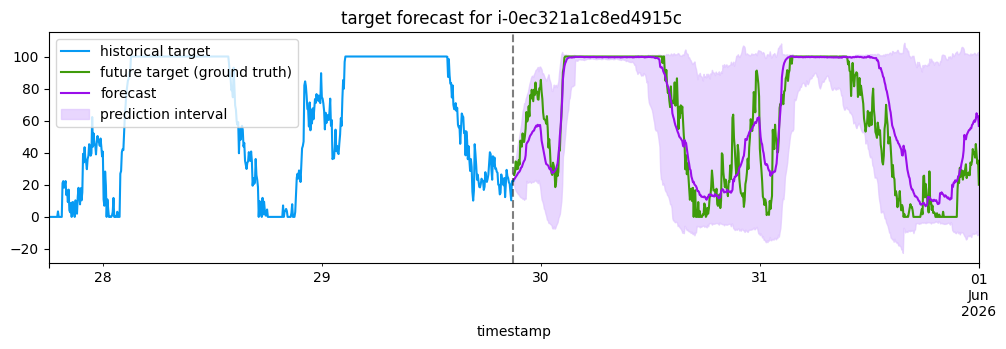

In [8]:
plot_forecast(
    context_df=mock_cpu_train,
    pred_df=pred_df,
    test_df=mock_cpu_test,
    target_column="target",
    timeseries_id="i-0ec321a1c8ed4915c",
    id_column="item_id",
    timestamp_column="timestamp",
    history_length=612,
    plot_name="univariate-mock"
)

In [9]:
err = quantify_error_rmse(mock_cpu_test, pred_df)

Root Mean Squared Error: 16.613952268310612


# Test Historical Covariate with Mock Data

In [10]:
mock_context_df.loc[(mock_context_df["item_id"] == "i-0ec321a1c8ed4915c")]["metricName"].unique()

mock_cpu_df = sherpa_get_feature(mock_context_df, "i-0ec321a1c8ed4915c", "CPUUtilization").drop(columns=["metricName"])
mock_network_in_df = sherpa_get_feature(mock_context_df, "i-0ec321a1c8ed4915c", "NetworkIn").drop(columns=["metricName"])
mock_disk_read_df = sherpa_get_feature(mock_context_df, "i-0ec321a1c8ed4915c", "DiskReadBytes").drop(columns=["metricName"])

mock_network_in_df = mock_network_in_df.rename(columns={"target": "NetworkIn"})
mock_disk_read_df = mock_disk_read_df.rename(columns={"target": "DiskRead"})

covariate_df = (
    mock_cpu_df
    .merge(mock_network_in_df, on=["item_id", "timestamp"])
    .merge(mock_disk_read_df, on=["item_id", "timestamp"])
)

print(covariate_df.info())
print(covariate_df[0:5])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8929 entries, 0 to 8928
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   item_id    8929 non-null   object        
 1   target     8929 non-null   float64       
 2   timestamp  8929 non-null   datetime64[ns]
 3   NetworkIn  8929 non-null   float64       
 4   DiskRead   8929 non-null   float64       
dtypes: datetime64[ns](1), float64(3), object(1)
memory usage: 348.9+ KB
None
               item_id     target           timestamp     NetworkIn  \
0  i-0ec321a1c8ed4915c  44.108112 2026-05-01 00:00:00  71729.757132   
1  i-0ec321a1c8ed4915c  32.426750 2026-05-01 00:05:00  64688.834524   
2  i-0ec321a1c8ed4915c  29.943384 2026-05-01 00:10:00  51356.239597   
3  i-0ec321a1c8ed4915c  28.484825 2026-05-01 00:15:00  44419.348569   
4  i-0ec321a1c8ed4915c  28.690147 2026-05-01 00:20:00  32927.378964   

       DiskRead  
0  75786.312647  
1  60898.705671  
2  552

In [11]:
test_size=612
mock_covariate_train = covariate_df.iloc[:-test_size].copy()
mock_covariate_test = covariate_df.iloc[-test_size:].copy()

In [12]:
pred_df = pipeline.predict_df(mock_covariate_train, prediction_length=test_size, quantile_levels=[0.1, 0.5, 0.9], target="target")

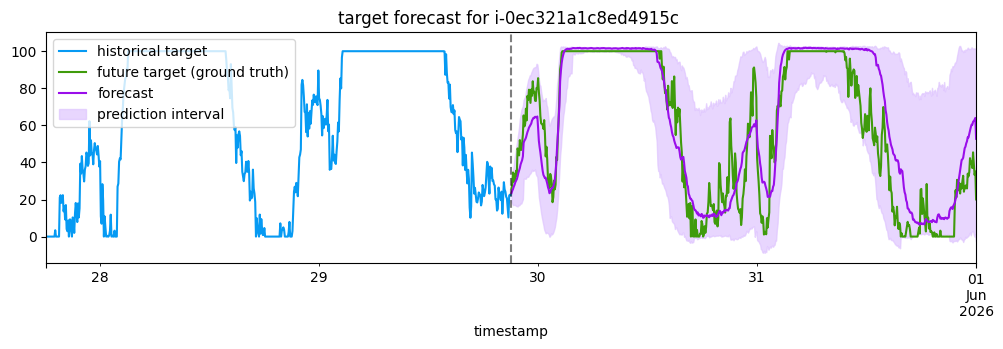

In [13]:
plot_forecast(
    context_df=mock_covariate_train,
    pred_df=pred_df,
    test_df=mock_covariate_test,
    target_column="target",
    timeseries_id="i-0ec321a1c8ed4915c",
    id_column="item_id",
    timestamp_column="timestamp",
    history_length=612,
)

In [14]:
mock_cpu_cv_rmse = quantify_error_rmse(mock_covariate_test, pred_df)

Root Mean Squared Error: 15.744787257672392


# Chronos Predictions on GCP Dataset

## Exploring the data

In [15]:
gcp_df = sherpa_chronos_preprocess(f"{DATASET_DIR}/gcpDataset.csv")
print(gcp_df.shape)
print(gcp_df.info())
display(gcp_df.head())

(72512, 4)
<class 'pandas.core.frame.DataFrame'>
Index: 72512 entries, 6639 to 71584
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   item_id     72512 non-null  object        
 1   target      72512 non-null  float64       
 2   metricName  72512 non-null  object        
 3   timestamp   72512 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 2.8+ MB
None


,item_id,target,metricName,timestamp
6639,806067928863076857,1.942000e+03,compute.googleapis.com/instance/disk/read_ops_...,2026-05-30 02:45:00
5975,806067928863076857,2.551309e+06,compute.googleapis.com/instance/disk/write_byt...,2026-05-30 02:45:00
1327,806067928863076857,2.500000e-01,compute.googleapis.com/instance/cpu/reserved_c...,2026-05-30 02:45:00
5311,806067928863076857,1.242228e+08,compute.googleapis.com/instance/disk/read_byte...,2026-05-30 02:45:00
3319,806067928863076857,6.252930e+05,compute.googleapis.com/instance/network/sent_b...,2026-05-30 02:45:00


In [16]:
gcp_df["metricName"].unique()

array(['compute.googleapis.com/instance/disk/read_ops_count',
       'compute.googleapis.com/instance/disk/write_bytes_count',
       'compute.googleapis.com/instance/cpu/reserved_cores',
       'compute.googleapis.com/instance/disk/read_bytes_count',
       'compute.googleapis.com/instance/network/sent_bytes_count',
       'compute.googleapis.com/instance/network/received_packets_count',
       'compute.googleapis.com/instance/network/received_bytes_count',
       'compute.googleapis.com/instance/disk/write_ops_count',
       'compute.googleapis.com/instance/network/sent_packets_count',
       'compute.googleapis.com/instance/cpu/usage_time',
       'compute.googleapis.com/instance/cpu/utilization'], dtype=object)

### All unique metricName values
- `compute.googleapis.com/instance/cpu/utilization`
- `compute.googleapis.com/instance/cpu/reserved_cores`
- `compute.googleapis.com/instance/cpu/usage_time`
- `compute.googleapis.com/instance/network/received_bytes_count`
- `compute.googleapis.com/instance/network/sent_bytes_count`
- `compute.googleapis.com/instance/network/received_packets_count`
- `compute.googleapis.com/instance/network/sent_packets_count`
- `compute.googleapis.com/instance/disk/read_bytes_count`
- `compute.googleapis.com/instance/disk/write_bytes_count`
- `compute.googleapis.com/instance/disk/read_ops_count`
- `compute.googleapis.com/instance/disk/write_ops_count`

## CPU univariate prediction

### Constructing dataframes

In [17]:
gcp_cpu_df = sherpa_get_feature(context_df=gcp_df, resource_id="806067928863076857", metricName="compute.googleapis.com/instance/cpu/utilization")
print(gcp_cpu_df.shape)

test_size=1024
gcp_cpu_train = gcp_cpu_df[:-test_size]
print(gcp_cpu_train.shape)

gcp_cpu_test = gcp_cpu_df[-test_size:]
print(gcp_cpu_test.shape)

print(gcp_cpu_train.head())

(6592, 4)
(5568, 4)
(1024, 4)
                item_id    target  \
663  806067928863076857  0.318452   
662  806067928863076857  0.265010   
661  806067928863076857  0.097326   
660  806067928863076857  0.084856   
659  806067928863076857  0.083133   

                                          metricName           timestamp  
663  compute.googleapis.com/instance/cpu/utilization 2026-05-30 02:45:00  
662  compute.googleapis.com/instance/cpu/utilization 2026-05-30 02:50:00  
661  compute.googleapis.com/instance/cpu/utilization 2026-05-30 02:55:00  
660  compute.googleapis.com/instance/cpu/utilization 2026-05-30 03:00:00  
659  compute.googleapis.com/instance/cpu/utilization 2026-05-30 03:05:00  


### Make prediction

In [18]:
pred_df = pipeline.predict_df(gcp_cpu_train, prediction_length=test_size, quantile_levels=[0.1, 0.5, 0.9])
print(pred_df.shape)

(1024, 7)


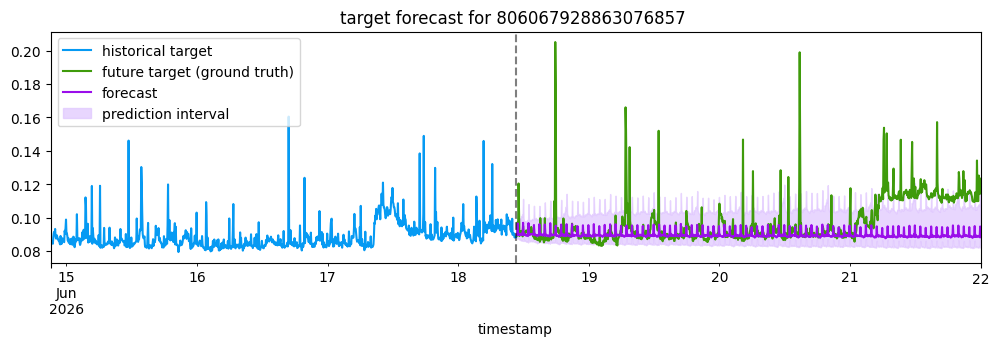

In [19]:
plot_forecast(
    context_df=gcp_cpu_train,
    pred_df=pred_df,
    test_df=gcp_cpu_test,
    target_column="target",
    timeseries_id="806067928863076857",
    id_column="item_id",
    timestamp_column="timestamp",
    history_length=1028,
    plot_name="gcp-cpu-univariate"
)

In [20]:
univariate_gcp_cpu_error = quantify_error_rmse(gcp_cpu_test, pred_df) 
print(f"{univariate_gcp_cpu_error * 100}%")

Root Mean Squared Error: 0.015493123635864442
1.549312363586444%


## CPU Historical Covariate Prediction

In [21]:
gcp_df = sherpa_chronos_preprocess(f"{DATASET_DIR}/gcpDataset.csv")
gcp_cpu_target_df = sherpa_combine_resources(context_df=gcp_df, resource_id="806067928863076857", target_metric="compute.googleapis.com/instance/cpu/utilization")

In [22]:
print(gcp_cpu_target_df.shape)
display(gcp_cpu_target_df.head())

(6592, 14)


,item_id,target,metricName,timestamp,compute.googleapis.com/instance/disk/read_ops_count,compute.googleapis.com/instance/disk/write_bytes_count,compute.googleapis.com/instance/cpu/reserved_cores,compute.googleapis.com/instance/disk/read_bytes_count,compute.googleapis.com/instance/network/sent_bytes_count,compute.googleapis.com/instance/network/received_packets_count,compute.googleapis.com/instance/network/received_bytes_count,compute.googleapis.com/instance/disk/write_ops_count,compute.googleapis.com/instance/network/sent_packets_count,compute.googleapis.com/instance/cpu/usage_time
0,806067928863076857,0.318452,compute.googleapis.com/instance/cpu/utilization,2026-05-30 02:45:00,1942.0,2551309.0,0.25,124222817.0,625293.0,502.0,368106.0,208.0,655.0,4.776783
1,806067928863076857,0.265010,compute.googleapis.com/instance/cpu/utilization,2026-05-30 02:50:00,1432.2,5217406.2,0.25,91442924.6,2498553.6,3409.4,2692858.6,538.8,3357.6,3.975156
2,806067928863076857,0.097326,compute.googleapis.com/instance/cpu/utilization,2026-05-30 02:55:00,29.2,3742779.2,0.25,860816.8,2300619.4,3572.4,2897766.6,459.8,3292.6,1.459886
3,806067928863076857,0.084856,compute.googleapis.com/instance/cpu/utilization,2026-05-30 03:00:00,270.8,3273280.8,0.25,3465827.2,2300160.4,3447.4,2900053.2,393.8,3235.8,1.272839
4,806067928863076857,0.083133,compute.googleapis.com/instance/cpu/utilization,2026-05-30 03:05:00,30.8,3251647.8,0.25,353217.2,2298997.2,3452.8,2898781.6,357.2,3226.6,1.246994


In [23]:
test_size=1024
gcp_cpu_train = gcp_cpu_target_df[:-test_size]
gcp_cpu_test = gcp_cpu_target_df[-test_size:]

In [24]:
pred_df = pipeline.predict_df(gcp_cpu_train, prediction_length=test_size, quantile_levels=[0.1, 0.5, 0.9], target="target")

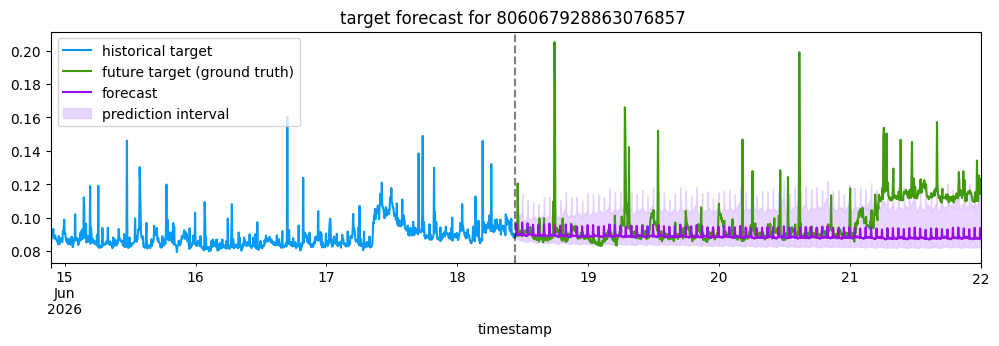

In [25]:
plot_forecast(
    context_df=gcp_cpu_train,
    pred_df=pred_df,
    test_df=gcp_cpu_test,
    target_column="target",
    timeseries_id="806067928863076857",
    id_column="item_id",
    timestamp_column="timestamp",
    history_length=1024,
    plot_name="gcp-cpu-covariate"
)

In [26]:
historical_cv_error = quantify_error_rmse(gcp_cpu_test, pred_df) 
print(f"{historical_cv_error * 100}%")

Root Mean Squared Error: 0.01600020179687703
1.6000201796877032%


# CPU True Covariate